# Neuroadaptive Haptics BCI results

- plots ERP from training condition for the four feedback conditions for all participants but the 'broken' participants with a color marking for the feature extraction time points
    - (compute MNE F-test for a main effect)
- descriptives of cross-validation, simulated chance level and plot interpolated ROC like in fastreach over all participants, print F1 score

In [1]:
import scipy.io as sio
import numpy as np
import os
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt
import sys, json
from collections import Counter
import mne

sys.path.append('/Users/lukasgehrke/Documents/publications/neuroadaptive-xr/neuroadaptive-xr')
from bci_funcs import bandpass_filter_fft

pIDs = [7,9,10,11,12,14,15,16,17,18,19,20,21,22]

path = '/Users/lukasgehrke/data/NAH/data/5_single-subject-EEG-analysis/'
fname = 'behavior_all.csv'
design = pd.read_csv(path + fname, delimiter=';')
design = design[['hapticProfile', 'id', 'bad_epoch', 'answerID']]

## ERPs

### Plot ERPs haptics contrast

In [ ]:
elecs = sio.loadmat(path+os.sep+'ERPs'+os.sep+'elecs.mat')['elecs']
elecs = [str(e[0]).replace('BrainVision RDA_', '') for e in elecs]
elecs = [e[2:-2] for e in elecs]

for elec in np.arange(0,64):

    df_all = pd.DataFrame()
    for id in pIDs:

        if id == 13 or id == 8:
            continue

        pID = 'sub-' + str(id)

        erp = sio.loadmat(path+os.sep+pID+os.sep+'erp.mat')['erp']
        erp = bandpass_filter_fft(erp, .1, 15, 250)

        # baseline correction
        baseline_time = np.arange(250, 262)
        erp = erp - erp[:,baseline_time,:].mean(axis=-2)[:,np.newaxis,:]
        erp = erp[elec,baseline_time[0]-25:baseline_time[0]+144,:]
        elec_erp = pd.DataFrame(erp).transpose()
        
        df_all = pd.concat([df_all, elec_erp], axis=0)

    # add design to df_all
    df_all = df_all.reset_index(drop=True)
    df_all = pd.concat([design, df_all], axis=1)

    # remove bad_epochs
    df_all = df_all[df_all['bad_epoch'] != 1]
    df_all = df_all.drop(columns='bad_epoch')

    # aggregate df_all by hapticProfile and id
    df_all = df_all.groupby(['hapticProfile', 'id']).mean().reset_index()

    # meldting the data
    df = df_all.melt(id_vars=['hapticProfile', 'id'], var_name='time', value_name='voltage').sort_values(by=['hapticProfile', 'id'])

    # time vector
    df['time'] = np.tile(np.arange(0, df_all.shape[1]-2), df_all.id.unique().shape[0] * df_all.hapticProfile.unique().shape[0])
    df['time'] = (df['time'] * 1/250 * 1000)-100
    # remove everything before > 600
    df = df[df['time'] < 576]

    with sns.plotting_context('paper', font_scale = 1.8):

        ### Create new plot
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
        fig.patch.set_alpha(1)

        sns.despine() #bottom=True, left=True

        # sns.lineplot(x='time', y='voltage', hue='condition', style='control', data=df, ax=ax, errorbar='ci')
        sns.lineplot(x='time', y='voltage', hue='hapticProfile', data=df, ax=ax, errorbar='ci')
        # sns.lineplot(x='time', y='voltage', hue='control', data=df, ax=ax, errorbar='ci')

        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Amplitude (μV)')

        # xline at 0 with text label 's'
        ax.axvline(0, color='black', linestyle='--')
        ax.text(.1, 0, 'grab', fontsize=14, rotation=90)

        # yline at 0
        ax.axhline(0, color='black', linestyle='--')

        # get min y value
        ymin = df['voltage'].min()

        # Mark area of feature extraction with a grey background from ymin to ymax
        ax.axvspan(100, 576, ymin=0, ymax=.05, color='black', alpha=0.2) #, label='features')
        ax.axvspan(0, 50, ymin=0, ymax=.05, color='black', alpha=0.1) #, label='baseline')

        # move legend to the right and make smaller
        # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), )
        ax.legend(loc='upper left', fontsize=8)

        # save as eps
        plt.tight_layout()
        plt.savefig(path+os.sep+'ERPs'+os.sep+elecs[elec]+'_haptics.pdf', format='pdf', dpi=300)

### Plot ERPs median split by answerID/preference rating

In [ ]:
elecs = sio.loadmat(path+os.sep+'ERPs'+os.sep+'elecs.mat')['elecs']
elecs = [str(e[0]).replace('BrainVision RDA_', '') for e in elecs]
elecs = [e[2:-2] for e in elecs]

for elec in np.arange(0,64):

    df_all = pd.DataFrame()
    for id in pIDs:

        if id == 13 or id == 8:
            continue

        pID = 'sub-' + str(id)

        erp = sio.loadmat(path+os.sep+pID+os.sep+'erp.mat')['erp']
        erp = bandpass_filter_fft(erp, .1, 15, 250)

        # baseline correction
        baseline_time = np.arange(250, 262)
        erp = erp - erp[:,baseline_time,:].mean(axis=-2)[:,np.newaxis,:]
        erp = erp[elec,baseline_time[0]-25:baseline_time[0]+144,:]
        elec_erp = pd.DataFrame(erp).transpose()
        
        df_all = pd.concat([df_all, elec_erp], axis=0)

    # add design to df_all
    df_all = df_all.reset_index(drop=True)
    df_all = pd.concat([design, df_all], axis=1)

    # remove bad_epochs
    df_all = df_all[df_all['bad_epoch'] != 1]
    df_all = df_all.drop(columns='bad_epoch')

    # Calculate the median 'answerID' for each 'id'
    medians = df_all.groupby('id')['answerID'].median().reset_index()
    medians.columns = ['id', 'median_answerID']

    # Merge the medians back into the original DataFrame
    df_all = pd.merge(df_all, medians, on='id')

    # Create the 'Preference' column based on the median
    df_all['Preference'] = df_all.apply(lambda row: 'high' if row['answerID'] > row['median_answerID'] else 'low', axis=1)

    # Drop the 'median_answerID' column as it's no longer needed
    df_all = df_all.drop(columns=['median_answerID', 'answerID', 'hapticProfile'])

    # aggregate df_all by id and Preference
    df_all = df_all.groupby(['Preference', 'id']).mean().reset_index()

    # meldting the data
    df = df_all.melt(id_vars=['Preference', 'id'], var_name='time', value_name='voltage').sort_values(by=['Preference', 'id'])

    # time vector
    df['time'] = np.tile(np.arange(0, df_all.shape[1]-2), df_all.id.unique().shape[0] * df_all.Preference.unique().shape[0])
    df['time'] = (df['time'] * 1/250 * 1000)-100
    df = df[df['time'] < 576]

    with sns.plotting_context('paper', font_scale = 1.8):

        ### Create new plot
        fig, ax = plt.subplots(1, 1, figsize=(5,3))
        fig.patch.set_alpha(1)

        sns.despine() #bottom=True, left=True

        # sns.lineplot(x='time', y='voltage', hue='condition', style='control', data=df, ax=ax, errorbar='ci')
        sns.lineplot(x='time', y='voltage', hue='Preference', data=df, ax=ax, errorbar='ci')
        # sns.lineplot(x='time', y='voltage', hue='control', data=df, ax=ax, errorbar='ci')

        ax.set_xlabel('Time (ms)')
        ax.set_ylabel('Amplitude (μV)')

        # xline at 0 with text label 's'
        ax.axvline(0, color='black', linestyle='--')
        ax.text(.1, 0, 'grab', fontsize=14, rotation=90)

        # yline at 0
        ax.axhline(0, color='black', linestyle='--')

        # get min y value
        ymin = df['voltage'].min()

        # Mark area of feature extraction with a grey background from ymin to ymax
        ax.axvspan(100, 576, ymin=0, ymax=.05, color='black', alpha=0.2) #, label='features')
        ax.axvspan(0, 50, ymin=0, ymax=.05, color='black', alpha=0.1) #, label='baseline')

        # move legend to the right and make smaller
        # ax.legend(loc='center left', bbox_to_anchor=(1, 0.5), )
        ax.legend(loc='upper left', fontsize=8)

        # save as eps
        plt.tight_layout()
        plt.savefig(path+os.sep+'ERPs'+os.sep+elecs[elec]+'_pref.pdf', format='pdf', dpi=300)

## BCI performance

In [2]:
nr_feats = []
f1 = []
acc = []
fprs = pd.DataFrame()
recalls = pd.DataFrame()

for pID in pIDs:
    this_pID = 'sub-' + str(pID)

    params = json.load(open(path+os.sep+this_pID+os.sep+'bci_params.json'))
    fpr = pd.read_csv(path+os.sep+this_pID+os.sep+'fpr.csv', header=None)
    recall = pd.read_csv(path+os.sep+this_pID+os.sep+'recall.csv', header=None)
    fprs = pd.concat([fprs, fpr], axis=1).reset_index(drop=True)
    recalls = pd.concat([recalls, recall], axis=1).reset_index(drop=True)
    
    nr_feats.append(params['best_set'])
    f1.append(params['f1'])
    acc.append(params['accuracy'])

In [3]:
# Mean and standard deviation of F1 scores
mean_f1 = np.mean(f1)
std_f1 = np.std(f1)
print(f"Mean F1 Score: {mean_f1:.4f}")
print(f"Standard Deviation of F1 Score: {std_f1:.4f}")

# Mean and standard deviation of accuracy
mean_acc = np.mean(acc)
std_acc = np.std(acc)
print(f"Mean Accuracy: {mean_acc:.4f}")
print(f"Standard Deviation of Accuracy: {std_acc:.4f}")

# Mean and standard deviation of number of features
mean_nr_feats = np.mean(nr_feats)
std_nr_feats = np.std(nr_feats)
print(f"Mean Number of Features: {mean_nr_feats:.4f}")
print(f"Standard Deviation of Number of Features: {std_nr_feats:.4f}")

Mean F1 Score: 0.8004
Standard Deviation of F1 Score: 0.0645
Mean Accuracy: 0.7990
Standard Deviation of Accuracy: 0.0642
Mean Number of Features: 40.7143
Standard Deviation of Number of Features: 25.0611


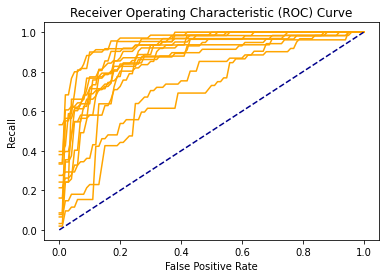

In [4]:
import matplotlib.pyplot as plt

def plot_roc_curve(fpr, tpr):
    plt.plot(fpr, tpr, color='orange', label='ROC')
    plt.plot([0, 1], [0, 1], color='darkblue', linestyle='--')
    plt.xlabel('False Positive Rate')
    plt.ylabel('Recall')
    plt.title('Receiver Operating Characteristic (ROC) Curve')
    # plt.legend()
    plt.show()

plot_roc_curve(fprs, recalls)

/var/folders/04/2q4w_vgn0_7dtkxyll6j2gx40000gn/T/ipykernel_16352/2190129900.py:22: UserWarning: 
The palette list has fewer values (1) than needed (14) and will cycle, which may produce an uninterpretable plot.
  ax = sns.lineplot(data = roc, x = 'value_x', y = 'value_y', hue = 'variable', palette = sns.color_palette(['black']), linewidth = 2, alpha = 0.2)
The PostScript backend does not support transparency; partially transparent artists will be rendered opaque.


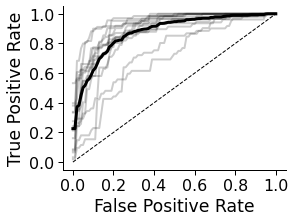

In [5]:
# rename columns of fprs and recalls to subject IDs that are increasing from 0
fprs.columns = np.arange(0, len(fprs.columns))
recalls.columns = np.arange(0, len(recalls.columns))

# wide to long format fprs and recalls and add column for subject IDs
fprs_long = pd.melt(fprs.reset_index(), id_vars=['index'], value_vars=fprs.columns)
recalls_long = pd.melt(recalls.reset_index(), id_vars=['index'], value_vars=recalls.columns)

# merge fprs and recalls
roc = pd.merge(fprs_long, recalls_long, on=['index', 'variable'])

roc_agg = roc.groupby(['value_x']).mean().reset_index()

with sns.plotting_context('paper', font_scale = 1.8):

    ### Create new plot
    fig, ax = plt.subplots(1, 1, figsize=(4,3))
    fig.patch.set_alpha(1)

    sns.despine() #bottom=True, left=True
    
    ax = sns.lineplot(data = roc, x = 'value_x', y = 'value_y', hue = 'variable', palette = sns.color_palette(['black']), linewidth = 2, alpha = 0.2)
    ax = sns.lineplot(data = roc_agg, x = 'value_x', y = 'value_y', color = 'black', linewidth = 3)

    # add a solid diagonal line
    ax.plot([0, 1], [0, 1], color='black', lw=1, linestyle='--')

    # add a vertical line at 0.15
    # ax.plot([0.15, .15], [0, 1.05], color='black', lw=1, linestyle='--')
    
    # Label and show
    # label_plot_for_subcats(ax)
    # ax.set_title(title)
    ax.set_ylabel('True Positive Rate')
    ax.set_xlabel('False Positive Rate')

    # hide legend
    ax.get_legend().remove()

    # plt.show()
    # plt.tight_layout()
    fig.savefig(path+os.sep+'roc' +'.pdf', format='pdf', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(path+os.sep+'roc' +'.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(path+os.sep+'roc' +'.png', format='png', transparent=True, bbox_inches='tight', dpi=300)

## BCI Descriptives

Summarize information about the channels selected, plot them potentially?

In [ ]:
import os
import json
import scipy.io as sio
import pandas as pd
from collections import Counter

# Load the elecs file
elecs_data = sio.loadmat(os.path.join(path, 'ERPs', 'elecs.mat'))['elecs']
elecs_list = [str(e[0]).replace('BrainVision RDA_', '') for e in elecs_data]
elecs_list = [e[2:-2] for e in elecs_list]

# Initialize variables
feature_counts = []
feature_inclusion_counts = Counter()
time_window_counts = Counter()  # Counter for the second dimension (time window)

# Process each participant's top features
for pID in pIDs:
    this_pID = 'sub-' + str(pID)
    json_file_path = os.path.join(path, this_pID, 'top_features_erp.json')
    
    with open(json_file_path, 'r') as file:
        top_features = json.load(file)
        feature_count = len(top_features)
        feature_counts.append(feature_count)
        
        # Update the feature inclusion counts
        for feature in top_features:
            feature_inclusion_counts[tuple(feature)] += 1
            time_window_counts[feature[1]] += 1  # Update the counter for the second dimension
            
# Match the first number in the tuple to the index in elecs_list and create a table with string of elec and count
elec_counts = Counter()
for feature in feature_inclusion_counts:
    elec_index = feature[0]
    elec_name = elecs_list[elec_index]
    elec_counts[elec_name] += feature_inclusion_counts[feature]

# Create a DataFrame with the results
elec_counts_df = pd.DataFrame.from_dict(elec_counts, orient='index', columns=['Count']).reset_index()
elec_counts_df.columns = ['Electrode', 'Count']

# Create a DataFrame for time window counts
time_window_counts_df = pd.DataFrame.from_dict(time_window_counts, orient='index', columns=['Count']).reset_index()
time_window_counts_df.columns = ['Time Window', 'Count']

print(elec_counts_df)
print(time_window_counts_df)
print(feature_counts)
print(feature_inclusion_counts)
print(time_window_counts)

# print mean and sd of feature counts
mean_feature_count = np.mean(feature_counts)
std_feature_count = np.std(feature_counts)
print(f"Mean Number of Features: {mean_feature_count:.4f}")
print(f"Standard Deviation of Number of Features: {std_feature_count:.4f}")


   Electrode  Count
0       TP10     20
1         T8     14
2        FT8     12
3         F6      5
4        CP5      9
..       ...    ...
59       CP2      7
60       CP6      6
61        P4      7
62       FT7      5
63        P2      5

[64 rows x 2 columns]
    Time Window  Count
0             9     84
1            10     46
2             8    105
3             5     32
4             7     74
5             4     33
6             2     52
7             6     55
8             0     27
9             3     24
10            1     38
[60, 35, 10, 20, 50, 30, 15, 70, 65, 45, 10, 10, 60, 90]
Counter({(25, 9): 4, (58, 9): 4, (20, 7): 4, (3, 8): 4, (20, 10): 3, (25, 7): 3, (55, 10): 3, (57, 9): 3, (55, 9): 3, (29, 8): 3, (54, 9): 3, (27, 9): 3, (60, 9): 3, (63, 9): 3, (63, 8): 3, (20, 8): 3, (60, 8): 3, (20, 6): 3, (55, 7): 3, (24, 5): 3, (47, 7): 3, (1, 6): 3, (56, 9): 3, (61, 7): 3, (6, 3): 3, (34, 8): 3, (4, 3): 3, (34, 1): 3, (41, 1): 3, (30, 8): 3, (26, 9): 3, (2, 8): 3, (38, 8): 3, (3

/var/folders/04/2q4w_vgn0_7dtkxyll6j2gx40000gn/T/ipykernel_16352/2730043462.py:11: FutureWarning: 

Passing `palette` without assigning `hue` is deprecated and will be removed in v0.14.0. Assign the `x` variable to `hue` and set `legend=False` for the same effect.

  sns.barplot(x='Time Window', y='Count', data=time_window_counts_df, ax=ax, palette='Blues_d')


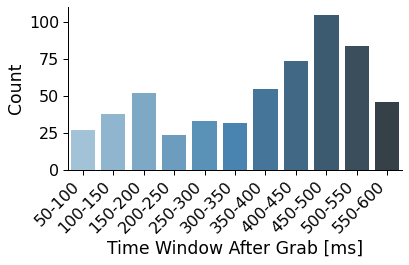

In [7]:
time_window_counts_df = time_window_counts_df.sort_values(by='Time Window', ascending=True)
time_window_counts_df['Time Window'] = time_window_counts_df['Time Window'].apply(lambda x: f'{x*50 + 50}-{x*50 + 100}')

# Plot the histogram of time window counts
title = 'histogram_time_window_counts'
with sns.plotting_context('paper', font_scale=1.8):
    fig, ax = plt.subplots(1, 1, figsize=(6, 3))
    fig.patch.set_alpha(1)

    sns.despine()
    sns.barplot(x='Time Window', y='Count', data=time_window_counts_df, ax=ax, palette='Blues_d')
    plt.xlabel('Time Window After Grab [ms]')
    plt.ylabel('Count')
    # plt.title('Histogram of Time Window Counts')
    plt.xticks(rotation=45, ha='right')  # Rotate x-ticks obliquely
    plt.show()

    fig.savefig(title + '.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
    fig.savefig(title + '.png', format='png', transparent=True, bbox_inches='tight', dpi=300)

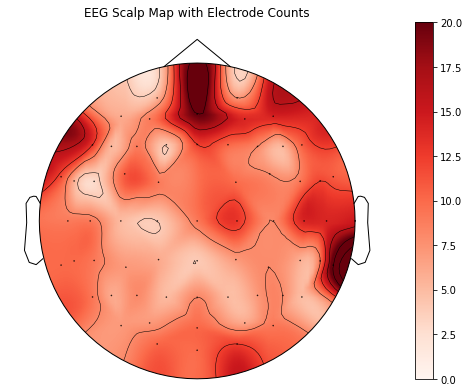

In [13]:
# Plot EEG scalp map using MNE-Python
# Create a montage with standard 10-20 electrode positions
montage = mne.channels.make_standard_montage('easycap-M1')

# Create an info object
info = mne.create_info(ch_names=montage.ch_names, sfreq=250, ch_types='eeg')
info.set_montage(montage)

# Create a data array with zeros
data = np.zeros((len(montage.ch_names), 1))

# Fill the data array with counts from elec_counts_df
for idx, row in elec_counts_df.iterrows():
    elec_name = row['Electrode']
    count = row['Count']
    if elec_name in montage.ch_names:
        data[montage.ch_names.index(elec_name), 0] = count

# Create an Evoked object
evoked = mne.EvokedArray(data, info)

# remove all channels that have a count of 0
evoked = evoked.pick_channels([ch for ch in evoked.ch_names if evoked.data[evoked.ch_names.index(ch), 0] > 0])

# Plot the scalp map
fig, ax = plt.subplots(1, 1, figsize=(10, 6))
im, _ = mne.viz.plot_topomap(evoked.data[:, 0], evoked.info, axes=ax, show=False) # RdBu_r
plt.colorbar(im, ax=ax)
plt.title('EEG Scalp Map with Electrode Counts')
plt.show()

title = 'scalp_map_electrode_counts'
fig.savefig(title + '.eps', format='eps', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(title + '.svg', format='svg', transparent=True, bbox_inches='tight', dpi=300)
fig.savefig(title + '.png', format='png', transparent=True, bbox_inches='tight', dpi=300)